# Appendix 02: Gaussian and Chi-square Distributions

Source orientation: printed pages 565-567; PDF pages 583-585.

This notebook is an original, standalone computational treatment of Appendix 02. The source span was used only to identify the section names and concepts: Gaussian probability distributions, covariance, Mahalanobis distance, change of coordinates, and the chi-square distribution. It does not reproduce textbook prose, figures, screenshots, page crops, or long table text.


## Chapter Goal

A vision residual is not just a length. It is a vector measured in the units and correlations of its covariance. Appendix 02 supplies the statistical bridge used throughout multiple-view geometry: a Gaussian residual model, a covariance matrix, the Mahalanobis distance, and chi-square gates that turn residual magnitudes into acceptance tests.

The notebook keeps the dimension small so the geometry is visible. A two-coordinate image residual stands in for reprojection error, Sampson error components, or any local residual vector that has been linearized around an estimate. The same calculations scale to larger residual vectors by changing the covariance and the chi-square degrees of freedom.


## Library Routing

This appendix uses SciPy statistics for Gaussian density and chi-square quantiles because the chapter target is probabilistic calibration of residual magnitudes, not a hand-coded distribution table. NumPy carries the covariance, whitening, and Mahalanobis computations so every matrix operation remains inspectable. Matplotlib is the right display layer here: covariance ellipses, confidence gates, and residual histograms are static diagnostic artifacts that must be easy to compare in exported notebooks.

For MVG residuals, the important habit is to report both the covariance units and the pixel-space interpretation. A gate is useful only when the model, dimension, and probability level are stated together.

## Translation Guide

- **Gaussian density:** a residual vector is modeled by a mean and covariance; the density decreases along ellipses of constant Mahalanobis distance.
- **Covariance:** diagonal terms set marginal variance, while off-diagonal terms rotate the uncertainty ellipse through correlation.
- **Mahalanobis distance:** the squared distance `r.T @ inv(Sigma) @ r` is the ordinary squared length after whitening.
- **Change of coordinates:** eigendecomposition of `Sigma` rotates into principal axes and scaling by inverse standard deviations makes the covariance approximately identity.
- **Chi-square gate:** if a residual is truly Gaussian with rank `r`, then its squared Mahalanobis distance follows a chi-square distribution with `r` degrees of freedom. A gate accepts residuals whose squared distance is below a chosen quantile.


## Route Through The Appendix

1. Build an anisotropic two-dimensional Gaussian residual model.
2. Draw its covariance ellipse and the whitening map that turns it into a circular cloud.
3. Draw Mahalanobis contours and label 68, 95, and 99 percent chi-square gates.
4. Sample many residuals, compare squared Mahalanobis values with the chi-square density, and measure empirical gate coverage.
5. Save a JSON invariant summary and finish with executable checks for artifacts, covariance, whitening, and coverage.


In [1]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
book_name = "Multiple-View-Geometry-in-Computer-Vision"
candidates = [START, *START.parents, START / book_name]
BOOK_ROOT = None
for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "appendix-02"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIGURE_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

source_span = {
    "printed_pages": "565-567",
    "pdf_pages": "583-585",
    "sections": ["A2.1 Gaussian probability distribution", "A2.2 chi-square distribution"],
}
source_span


{'printed_pages': '565-567',
 'pdf_pages': '583-585',
 'sections': ['A2.1 Gaussian probability distribution',
  'A2.2 chi-square distribution']}

## Visual Storyboard

| Visual | Concept | Representation and library | Learner inspection target | Check or invariant |
| --- | --- | --- | --- | --- |
| `figures/covariance-whitening-ellipse.png` | covariance and coordinate change | Matplotlib scatter, covariance ellipse, eigenframe, whitened residuals | anisotropic residuals become circular after whitening | whitened sample covariance is close to identity |
| `figures/mahalanobis-chi-square-gates.png` | Mahalanobis distance and confidence gates | Matplotlib contours from `r.T @ inv(Sigma) @ r`, SciPy chi-square quantiles | 68/95/99 percent gates are ellipses in residual coordinates and circles in whitened coordinates | quantiles match `scipy.stats.chi2.ppf` |
| `figures/chi-square-residual-diagnostic.png` | residual diagnostics | Matplotlib histogram and coverage bars, SciPy chi-square density | squared Mahalanobis samples follow the chi-square reference when the covariance is right | empirical coverage is near target coverage |
| `checks/gaussian-chi-square-invariants.json` | lab summary | JSON written with the course artifact helper | residual vectors map to acceptance gates | PSD covariance, identity whitening, and coverage tolerances |


In [2]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
from scipy.stats import chi2, multivariate_normal

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib

rng = np.random.default_rng(202602)
mean = np.array([0.55, -0.35])
Sigma = np.array([[4.0, 1.45], [1.45, 0.95]])
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
Sigma_inv = np.linalg.inv(Sigma)
Sigma_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
Sigma_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

n_samples = 12000
samples = rng.multivariate_normal(mean, Sigma, size=n_samples)
residuals = samples - mean
whitened = residuals @ Sigma_inv_sqrt.T
sample_cov = np.cov(residuals, rowvar=False)
whitened_cov = np.cov(whitened, rowvar=False)
d2 = np.einsum("...i,ij,...j->...", residuals, Sigma_inv, residuals)
probabilities = np.array([0.68, 0.95, 0.99])
quantiles = chi2.ppf(probabilities, df=2)
empirical_coverage = np.array([(d2 <= q).mean() for q in quantiles])
artifact_paths = []

palette = {
    "ink": "#1f2933",
    "blue": "#2563eb",
    "green": "#0f766e",
    "gold": "#b45309",
    "red": "#b91c1c",
    "gray": "#6b7280",
}

assert np.all(eigvals > 0), "The covariance used for the lab must be positive definite."


## Covariance Ellipse And Whitening Map

The Gaussian density is easiest to inspect through its level sets. In raw residual coordinates, correlation tilts the ellipse and unequal variances stretch it. Whitening applies the inverse square root of the covariance, so the same residuals become approximately circular and their covariance becomes approximately the identity matrix.

For a vision estimator, this is the practical meaning of covariance weighting: a one-pixel residual along a high-variance direction should not count the same as a one-pixel residual along a tightly constrained direction.


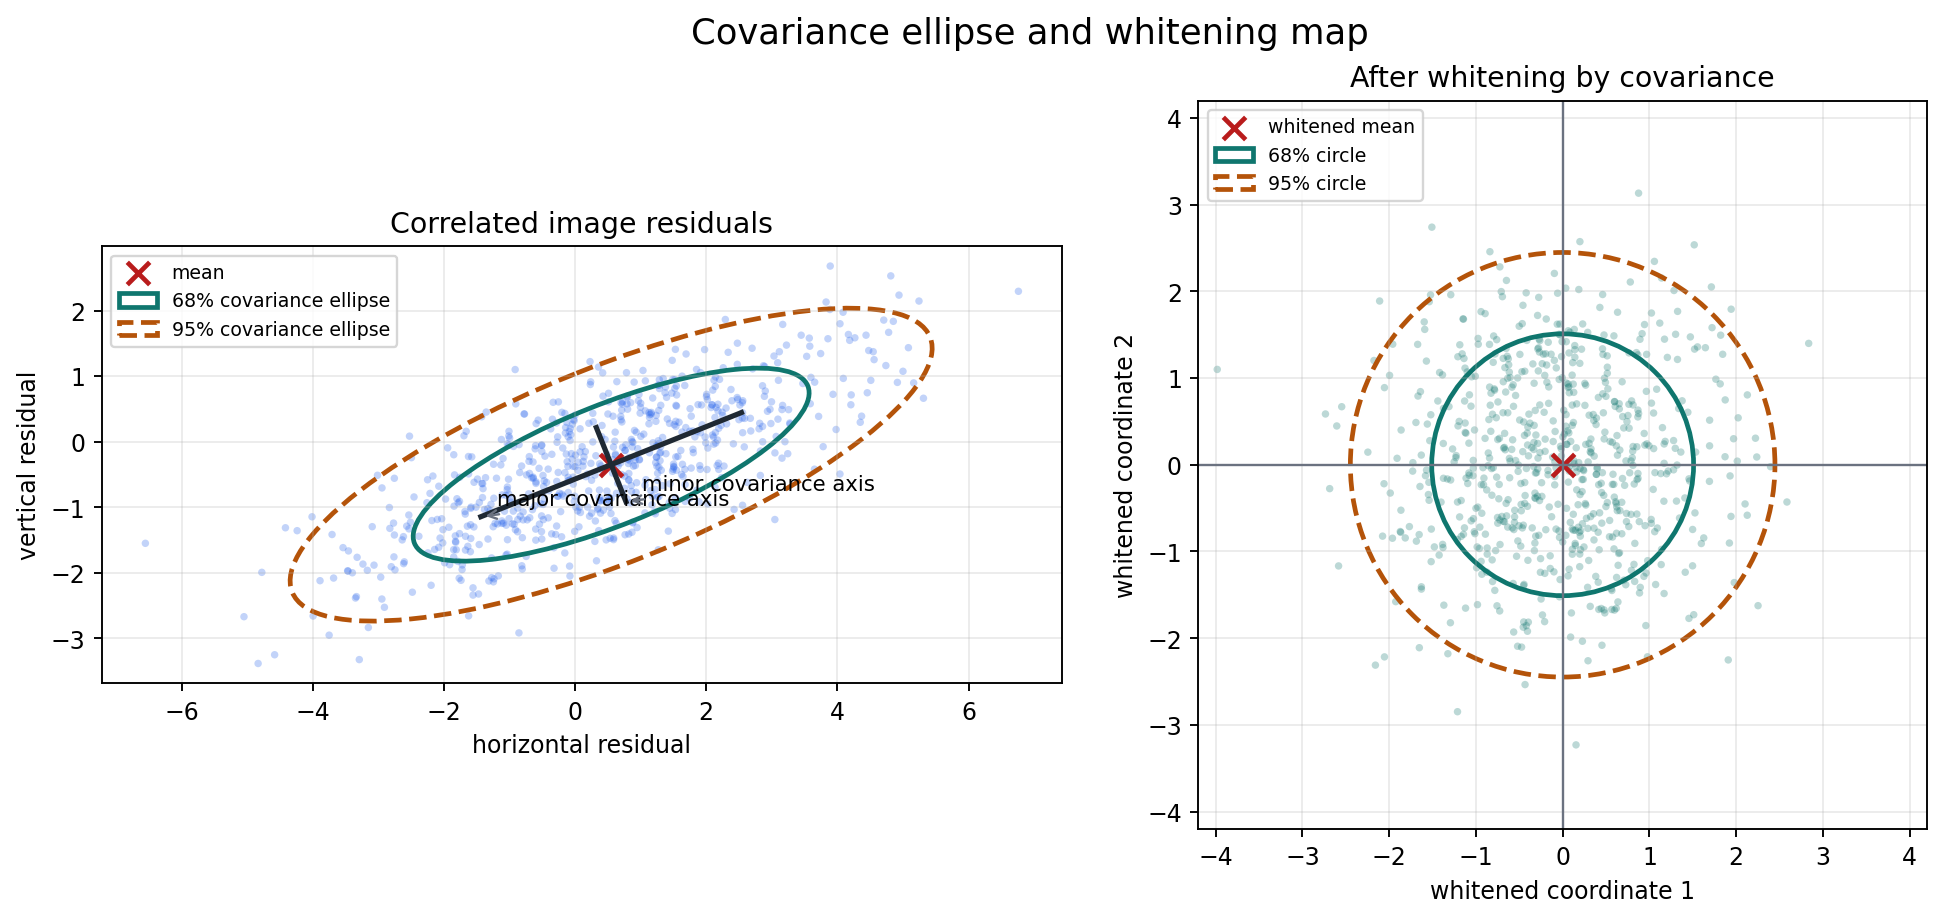

{'sample_covariance': [[3.9208, 1.4097], [1.4097, 0.9355]],
 'whitened_covariance': [[0.9868, -0.0153], [-0.0153, 1.0035]],
 'max_identity_error': 0.015289843468848674}

In [3]:
def confidence_ellipse(ax, center, cov, probability, *, edgecolor, label=None, linestyle="-", linewidth=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = math.degrees(math.atan2(vecs[1, 0], vecs[0, 0]))
    scale = math.sqrt(chi2.ppf(probability, df=2))
    width, height = 2.0 * scale * np.sqrt(vals)
    patch = Ellipse(center, width, height, angle=angle, fill=False,
                    edgecolor=edgecolor, linestyle=linestyle, linewidth=linewidth, label=label)
    ax.add_patch(patch)
    return patch

fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), constrained_layout=True)
raw_ax, white_ax = axes
subset = slice(0, 700)

raw_ax.scatter(samples[subset, 0], samples[subset, 1], s=10, alpha=0.28, color=palette["blue"], edgecolors="none")
raw_ax.scatter([mean[0]], [mean[1]], marker="x", s=90, color=palette["red"], linewidths=2, label="mean")
confidence_ellipse(raw_ax, mean, Sigma, 0.68, edgecolor=palette["green"], label="68% covariance ellipse")
confidence_ellipse(raw_ax, mean, Sigma, 0.95, edgecolor=palette["gold"], label="95% covariance ellipse", linestyle="--")
for val, vec, name in zip(eigvals, eigvecs.T, ["major covariance axis", "minor covariance axis"]):
    start = mean - np.sqrt(val) * vec
    end = mean + np.sqrt(val) * vec
    raw_ax.plot([start[0], end[0]], [start[1], end[1]], color=palette["ink"], linewidth=2.2)
    raw_ax.annotate(name, xy=end, xytext=end + np.array([0.25, 0.18]), fontsize=9,
                    arrowprops={"arrowstyle": "->", "color": palette["gray"], "lw": 1.0})
raw_ax.set_title("Correlated image residuals")
raw_ax.set_xlabel("horizontal residual")
raw_ax.set_ylabel("vertical residual")
raw_ax.set_aspect("equal", adjustable="box")
raw_ax.grid(True, alpha=0.25)
raw_ax.legend(loc="upper left", fontsize=8)

white_ax.scatter(whitened[subset, 0], whitened[subset, 1], s=10, alpha=0.28, color=palette["green"], edgecolors="none")
white_ax.scatter([0], [0], marker="x", s=90, color=palette["red"], linewidths=2, label="whitened mean")
confidence_ellipse(white_ax, np.zeros(2), np.eye(2), 0.68, edgecolor=palette["green"], label="68% circle")
confidence_ellipse(white_ax, np.zeros(2), np.eye(2), 0.95, edgecolor=palette["gold"], label="95% circle", linestyle="--")
white_ax.axhline(0, color=palette["gray"], linewidth=1)
white_ax.axvline(0, color=palette["gray"], linewidth=1)
white_ax.set_title("After whitening by covariance")
white_ax.set_xlabel("whitened coordinate 1")
white_ax.set_ylabel("whitened coordinate 2")
white_ax.set_xlim(-4.2, 4.2)
white_ax.set_ylim(-4.2, 4.2)
white_ax.set_aspect("equal", adjustable="box")
white_ax.grid(True, alpha=0.25)
white_ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Covariance ellipse and whitening map", fontsize=15)
ellipse_path = save_matplotlib(fig, TOPIC, "figures", "covariance-whitening-ellipse.png", dpi=170)
plt.close(fig)
artifact_paths.append(ellipse_path)
display_artifact(ellipse_path, width=900)

{
    "sample_covariance": sample_cov.round(4).tolist(),
    "whitened_covariance": whitened_cov.round(4).tolist(),
    "max_identity_error": float(np.max(np.abs(whitened_cov - np.eye(2)))),
}


## Mahalanobis Contours And Chi-square Gates

A Euclidean contour would be a circle in raw residual coordinates, but the Gaussian density uses covariance-aware distance. The squared Mahalanobis distance

```text
d^2 = (x - mean).T @ inv(Sigma) @ (x - mean)
```

is exactly the squared radius after whitening. Because the residual dimension here is two, the gate thresholds are chi-square quantiles with two degrees of freedom. Points inside the 95 percent gate are not automatically correct; they are residuals whose magnitude is statistically plausible under this covariance model.


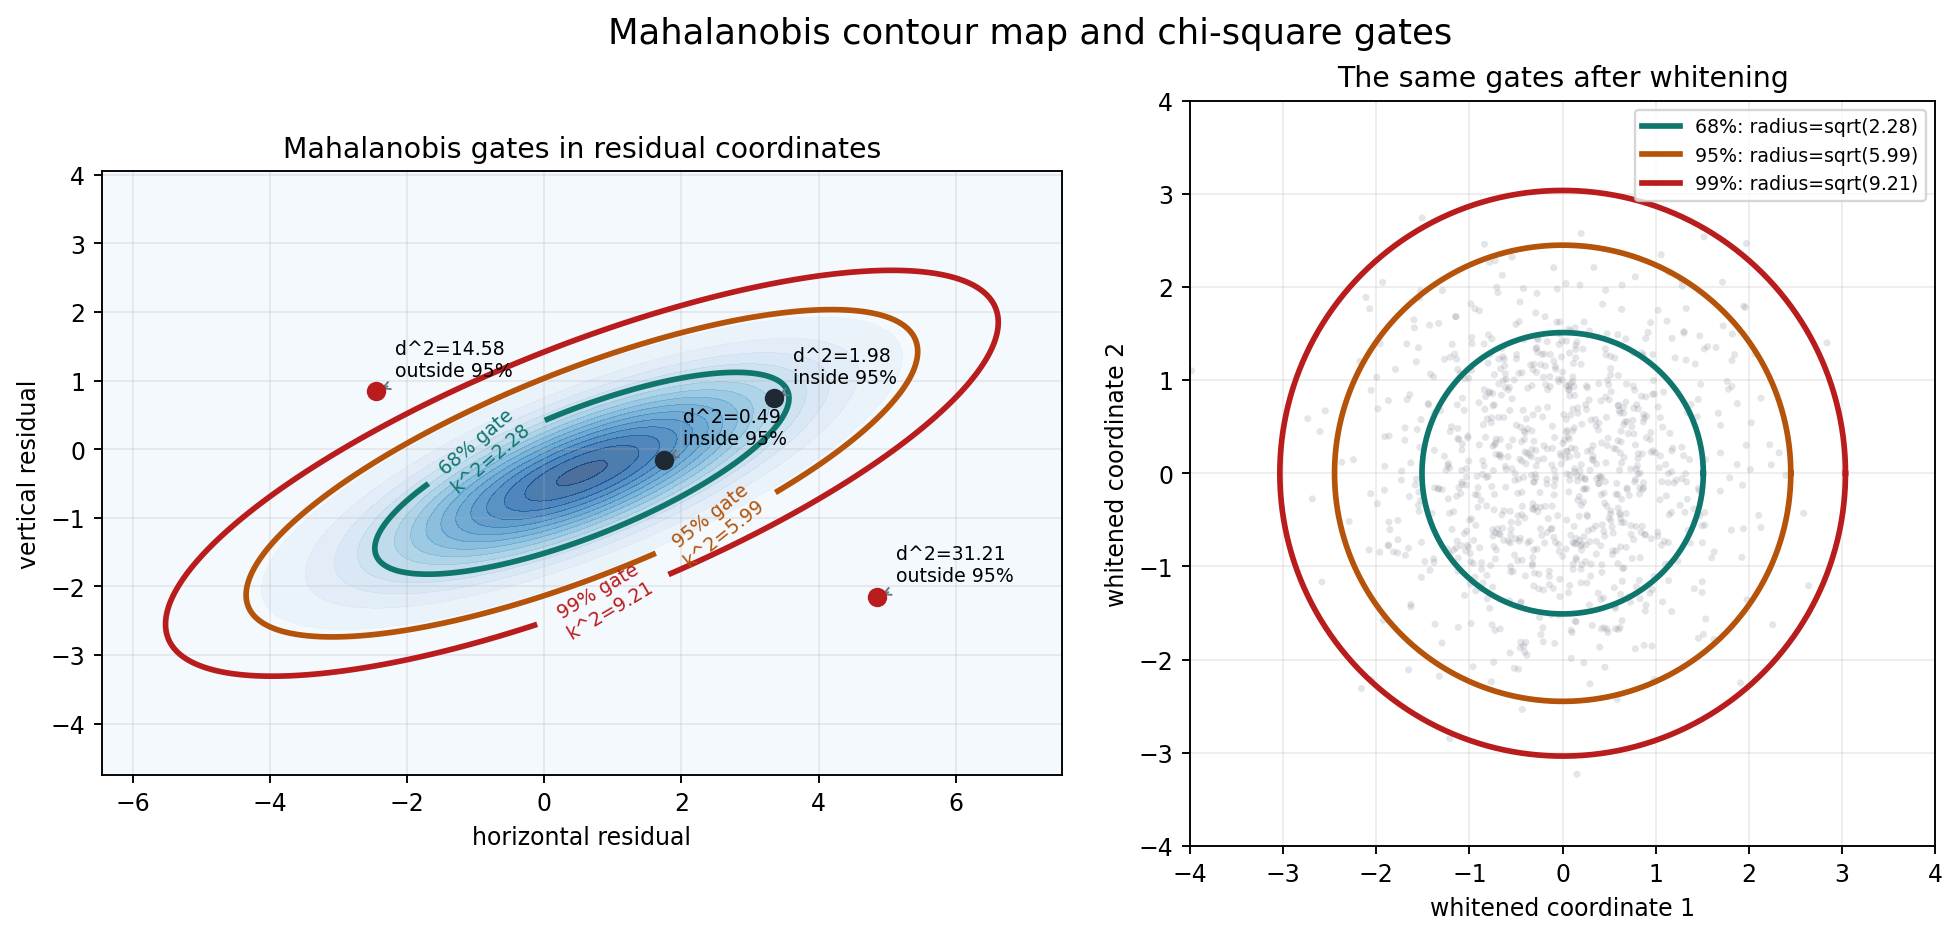

{'chi2_df2_quantile_0.68': 2.27886856637673,
 'chi2_df2_quantile_0.95': 5.991464547107979,
 'chi2_df2_quantile_0.99': 9.21034037197618}

In [4]:
x = np.linspace(mean[0] - 7.0, mean[0] + 7.0, 240)
y = np.linspace(mean[1] - 4.4, mean[1] + 4.4, 220)
X, Y = np.meshgrid(x, y)
grid = np.stack([X - mean[0], Y - mean[1]], axis=-1)
D2 = np.einsum("...i,ij,...j->...", grid, Sigma_inv, grid)
Z = multivariate_normal(mean=mean, cov=Sigma).pdf(np.stack([X, Y], axis=-1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)
contour_ax, white_gate_ax = axes
levels = quantiles
colors = [palette["green"], palette["gold"], palette["red"]]

contour_ax.contourf(X, Y, Z, levels=18, cmap="Blues", alpha=0.72)
cs = contour_ax.contour(X, Y, D2, levels=levels, colors=colors, linewidths=2.4)
fmt = {level: f"{int(prob * 100)}% gate\nk^2={level:.2f}" for level, prob in zip(levels, probabilities)}
contour_ax.clabel(cs, fmt=fmt, fontsize=8, inline=True)
trial_residuals = np.array([[1.2, 0.2], [2.8, 1.1], [-3.0, 1.2], [4.3, -1.8]])
trial_points = mean + trial_residuals
trial_d2 = np.einsum("...i,ij,...j->...", trial_residuals, Sigma_inv, trial_residuals)
for point, value in zip(trial_points, trial_d2):
    status = "inside 95%" if value <= quantiles[1] else "outside 95%"
    contour_ax.scatter(point[0], point[1], s=52, color=palette["ink"] if value <= quantiles[1] else palette["red"], zorder=5)
    contour_ax.annotate(f"d^2={value:.2f}\n{status}", xy=point, xytext=(point[0] + 0.28, point[1] + 0.22),
                        fontsize=8, arrowprops={"arrowstyle": "->", "lw": 0.8, "color": palette["gray"]})
contour_ax.set_title("Mahalanobis gates in residual coordinates")
contour_ax.set_xlabel("horizontal residual")
contour_ax.set_ylabel("vertical residual")
contour_ax.set_aspect("equal", adjustable="box")
contour_ax.grid(True, alpha=0.22)

white_subset = whitened[:900]
white_gate_ax.scatter(white_subset[:, 0], white_subset[:, 1], s=9, alpha=0.18, color=palette["gray"], edgecolors="none")
theta = np.linspace(0, 2 * np.pi, 400)
for q, prob, color in zip(quantiles, probabilities, colors):
    radius = math.sqrt(q)
    white_gate_ax.plot(radius * np.cos(theta), radius * np.sin(theta), color=color, linewidth=2.4, label=f"{int(prob*100)}%: radius=sqrt({q:.2f})")
white_gate_ax.set_title("The same gates after whitening")
white_gate_ax.set_xlabel("whitened coordinate 1")
white_gate_ax.set_ylabel("whitened coordinate 2")
white_gate_ax.set_xlim(-4.0, 4.0)
white_gate_ax.set_ylim(-4.0, 4.0)
white_gate_ax.set_aspect("equal", adjustable="box")
white_gate_ax.grid(True, alpha=0.22)
white_gate_ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Mahalanobis contour map and chi-square gates", fontsize=15)
gates_path = save_matplotlib(fig, TOPIC, "figures", "mahalanobis-chi-square-gates.png", dpi=170)
plt.close(fig)
artifact_paths.append(gates_path)
display_artifact(gates_path, width=900)

{f"chi2_df2_quantile_{prob:.2f}": float(q) for prob, q in zip(probabilities, quantiles)}


## Residual Histogram Vs Chi-square Diagnostic

The gate is only as good as the covariance model. If residuals are Gaussian with covariance `Sigma`, then the squared Mahalanobis values should look like a chi-square distribution with two degrees of freedom. This diagnostic is a compact way to catch underestimated covariance, ignored correlation, or outliers.

The right panel measures the same idea as coverage: about 68, 95, and 99 percent of correctly modeled residuals should fall inside the corresponding gates. In a real reconstruction pipeline, this is the place to compare residuals from feature tracks, reprojection equations, or robust-estimator inliers.


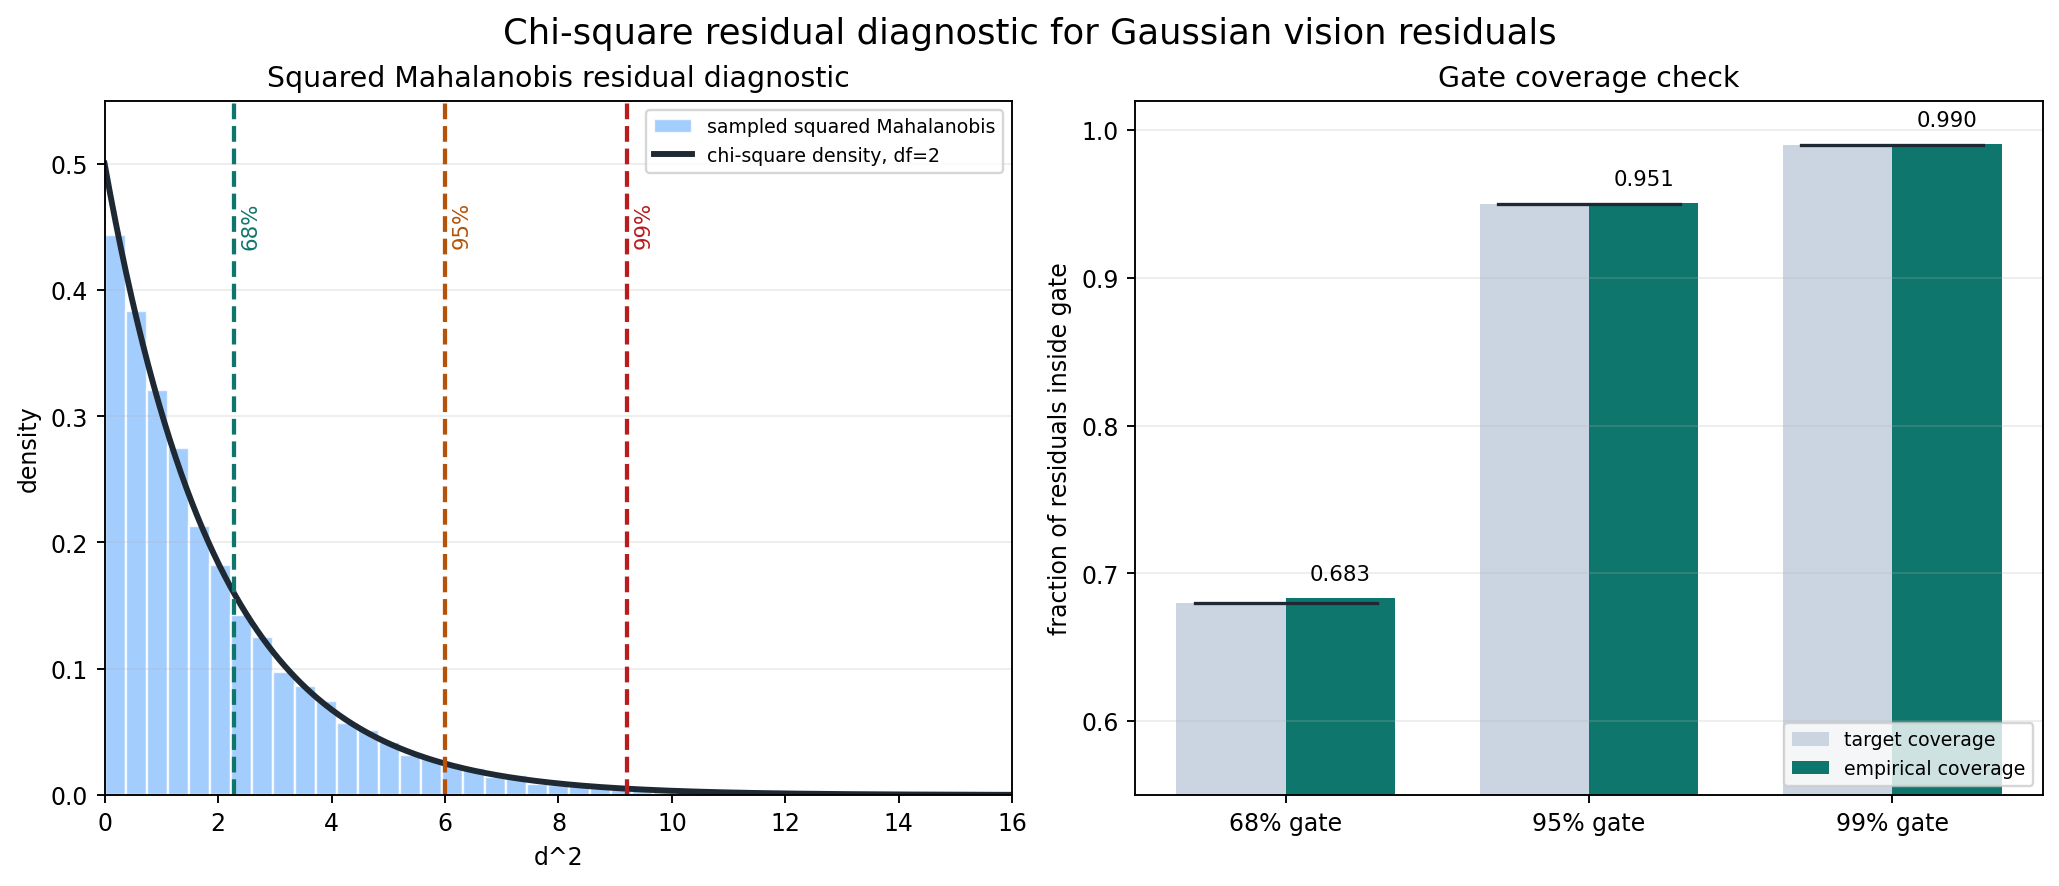

[{'target': 0.68,
  'chi2_quantile': 2.27886856637673,
  'empirical': 0.6834166666666667,
  'absolute_error': 0.0034166666666666234},
 {'target': 0.95,
  'chi2_quantile': 5.991464547107979,
  'empirical': 0.9508333333333333,
  'absolute_error': 0.0008333333333333526},
 {'target': 0.99,
  'chi2_quantile': 9.21034037197618,
  'empirical': 0.9904166666666666,
  'absolute_error': 0.0004166666666666208}]

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.1), constrained_layout=True)
hist_ax, coverage_ax = axes

bins = np.linspace(0, 16, 44)
hist_ax.hist(d2, bins=bins, density=True, color="#93c5fd", edgecolor="white", alpha=0.85, label="sampled squared Mahalanobis")
xx = np.linspace(0, 16, 500)
hist_ax.plot(xx, chi2.pdf(xx, df=2), color=palette["ink"], linewidth=2.5, label="chi-square density, df=2")
for q, prob, color in zip(quantiles, probabilities, colors):
    hist_ax.axvline(q, color=color, linestyle="--", linewidth=1.8)
    hist_ax.text(q + 0.12, 0.47, f"{int(prob*100)}%", color=color, fontsize=9, rotation=90, va="top")
hist_ax.set_title("Squared Mahalanobis residual diagnostic")
hist_ax.set_xlabel("d^2")
hist_ax.set_ylabel("density")
hist_ax.set_xlim(0, 16)
hist_ax.set_ylim(0, 0.55)
hist_ax.grid(True, axis="y", alpha=0.22)
hist_ax.legend(fontsize=8)

xpos = np.arange(len(probabilities))
width = 0.36
coverage_ax.bar(xpos - width/2, probabilities, width=width, color="#cbd5e1", label="target coverage")
coverage_ax.bar(xpos + width/2, empirical_coverage, width=width, color=palette["green"], label="empirical coverage")
for i, (target, observed) in enumerate(zip(probabilities, empirical_coverage)):
    coverage_ax.plot([i - 0.3, i + 0.3], [target, target], color=palette["ink"], linewidth=1.4)
    coverage_ax.text(i + width/2, observed + 0.012, f"{observed:.3f}", ha="center", fontsize=9)
coverage_ax.set_xticks(xpos, ["68% gate", "95% gate", "99% gate"])
coverage_ax.set_ylim(0.55, 1.02)
coverage_ax.set_ylabel("fraction of residuals inside gate")
coverage_ax.set_title("Gate coverage check")
coverage_ax.grid(True, axis="y", alpha=0.22)
coverage_ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Chi-square residual diagnostic for Gaussian vision residuals", fontsize=15)
diagnostic_path = save_matplotlib(fig, TOPIC, "figures", "chi-square-residual-diagnostic.png", dpi=170)
plt.close(fig)
artifact_paths.append(diagnostic_path)
display_artifact(diagnostic_path, width=900)

coverage_table = [
    {"target": float(target), "chi2_quantile": float(q), "empirical": float(obs), "absolute_error": float(abs(obs - target))}
    for target, q, obs in zip(probabilities, quantiles, empirical_coverage)
]
coverage_table


## Applied Lab: Vision Residual Covariance Summary

Suppose a local bundle-adjustment step reports two-coordinate residuals for one image measurement type. The workflow is:

1. estimate or choose the residual covariance;
2. whiten residuals before comparing magnitudes;
3. use the chi-square quantile for the residual rank as the acceptance gate;
4. monitor empirical coverage over many residuals.

The JSON below is a reproducible lab summary. It records the covariance model, the whitening check, the chi-square gates, and the empirical coverage. Downstream chapters can read the same contract when deciding whether a residual is plausible or should be treated as an outlier candidate.


In [6]:
invariant_summary = {
    "title": "Gaussian and Chi-square Distributions",
    "source_span": source_span,
    "residual_dimension": 2,
    "mean": mean.tolist(),
    "covariance": Sigma.tolist(),
    "covariance_eigenvalues": eigvals.tolist(),
    "covariance_is_psd": bool(np.all(np.linalg.eigvalsh(Sigma) > 0)),
    "sample_covariance": sample_cov.tolist(),
    "whitened_covariance": whitened_cov.tolist(),
    "whitening_max_identity_error": float(np.max(np.abs(whitened_cov - np.eye(2)))),
    "chi_square_quantiles": {str(float(p)): float(q) for p, q in zip(probabilities, quantiles)},
    "empirical_gate_coverage": {str(float(p)): float(c) for p, c in zip(probabilities, empirical_coverage)},
    "max_gate_coverage_error": float(np.max(np.abs(empirical_coverage - probabilities))),
    "diagnostic_rule": "accept a two-coordinate residual at probability alpha when squared Mahalanobis distance <= chi2.ppf(alpha, df=2)",
    "libraries": ["numpy", "scipy.stats", "matplotlib"],
}
summary_path = save_json(invariant_summary, TOPIC, "checks", "gaussian-chi-square-invariants.json")
display_artifact(summary_path)
invariant_summary


`artifacts/appendix-02/checks/gaussian-chi-square-invariants.json`

{'title': 'Gaussian and Chi-square Distributions',
 'source_span': {'printed_pages': '565-567',
  'pdf_pages': '583-585',
  'sections': ['A2.1 Gaussian probability distribution',
   'A2.2 chi-square distribution']},
 'residual_dimension': 2,
 'mean': [0.55, -0.35],
 'covariance': [[4.0, 1.45], [1.45, 0.95]],
 'covariance_eigenvalues': [4.579311051151897, 0.3706889488481034],
 'covariance_is_psd': True,
 'sample_covariance': [[3.9208153433216975, 1.4096804233898896],
  [1.4096804233898896, 0.9354752434149729]],
 'whitened_covariance': [[0.9868223070641383, -0.015289843468848674],
  [-0.015289843468848674, 1.0035177942523985]],
 'whitening_max_identity_error': 0.015289843468848674,
 'chi_square_quantiles': {'0.68': 2.27886856637673,
  '0.95': 5.991464547107979,
  '0.99': 9.21034037197618},
 'empirical_gate_coverage': {'0.68': 0.6834166666666667,
  '0.95': 0.9508333333333333,
  '0.99': 0.9904166666666666},
 'max_gate_coverage_error': 0.0034166666666666234,
 'diagnostic_rule': 'accept a tw

## Pitfalls And Failure Modes

- **Using Euclidean gates on anisotropic residuals:** a raw circular gate ignores covariance orientation and variance, so it can reject plausible residuals along a noisy direction while accepting implausible residuals along a precise direction.
- **Forgetting the degrees of freedom:** the chi-square threshold changes with residual rank. A scalar residual, a two-coordinate image residual, and a larger stacked residual need different gates.
- **Treating the covariance as decoration:** the inverse covariance is part of the distance. A badly scaled or non-PSD covariance can make residual diagnostics meaningless.
- **Confusing density with acceptance:** high density near the mean and gate coverage are related, but the gate is a cumulative probability statement, not a statement that every accepted residual is correct.
- **Ignoring singular covariance:** if covariance is singular, the pseudo-inverse and the covariance rank replace the inverse and full dimension. The same gate idea survives, but the rank must be explicit.


## Final Sanity Checks

The checks below keep the notebook honest as a reproducible artifact. They verify the three PNG figures, the JSON summary, positive definiteness of covariance, whitening to identity, and empirical coverage against the target chi-square probabilities.


In [7]:
figure_artifacts = [ellipse_path, gates_path, diagnostic_path]
expected_artifacts = [*figure_artifacts, summary_path]
assert_artifacts(figure_artifacts, min_bytes=1500)
assert_artifacts([summary_path], min_bytes=32)
assert np.all(np.linalg.eigvalsh(Sigma) > 0), "Covariance must be positive definite for this inverse-covariance lab."
assert np.max(np.abs(whitened_cov - np.eye(2))) < 0.04, whitened_cov
assert np.allclose(quantiles, chi2.ppf(probabilities, df=2))
assert np.max(np.abs(empirical_coverage - probabilities)) < 0.015, empirical_coverage

with open(summary_path, "r", encoding="utf-8") as handle:
    saved_summary = json.load(handle)
assert saved_summary["covariance_is_psd"] is True
assert saved_summary["max_gate_coverage_error"] < 0.015

final_sanity = {
    "artifact_count": len(expected_artifacts),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in expected_artifacts],
    "covariance_eigenvalues": eigvals.round(6).tolist(),
    "whitening_max_identity_error": float(np.max(np.abs(whitened_cov - np.eye(2)))),
    "max_gate_coverage_error": float(np.max(np.abs(empirical_coverage - probabilities))),
}
final_sanity


{'artifact_count': 4,
 'artifacts': ['artifacts//appendix-02//figures//covariance-whitening-ellipse.png',
  'artifacts//appendix-02//figures//mahalanobis-chi-square-gates.png',
  'artifacts//appendix-02//figures//chi-square-residual-diagnostic.png',
  'artifacts//appendix-02//checks//gaussian-chi-square-invariants.json'],
 'covariance_eigenvalues': [4.579311, 0.370689],
 'whitening_max_identity_error': 0.015289843468848674,
 'max_gate_coverage_error': 0.0034166666666666234}

## Takeaways

- A Gaussian residual model is determined by mean and covariance; covariance controls both scale and direction.
- Mahalanobis distance is Euclidean distance after whitening, so covariance-weighted residuals can be compared fairly.
- In two residual dimensions, squared Mahalanobis distances should follow a chi-square distribution with two degrees of freedom when the model is correct.
- Chi-square gates are cumulative probability tests. They are useful for residual diagnostics, but they must be paired with a valid covariance model and the correct residual rank.
